In [9]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

In [10]:

# ===============================
# 2. LOAD DATA
# ===============================
data_path = os.path.join("..", "data", "raw", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(data_path)

print("Dataset Loaded Successfully\n")


Dataset Loaded Successfully



In [11]:

# ===============================
# 3. BASIC INFO
# ===============================
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())

print("\nData Types:\n")
print(df.dtypes)

print("\nFirst 5 Rows:\n")
display(df.head())


Shape of dataset: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

First 5 Rows:



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
#  ===============================
# 4. DATA CLEANING
# ===============================

# Convert TotalCharges to numeric (important fix)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Fill missing values with median
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
# 


Missing Values:

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


C:\Users\Saqib\AppData\Local\Temp\ipykernel_23336\1705027061.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64


Target Distribution:

Churn
No     5174
Yes    1869
Name: count, dtype: int64


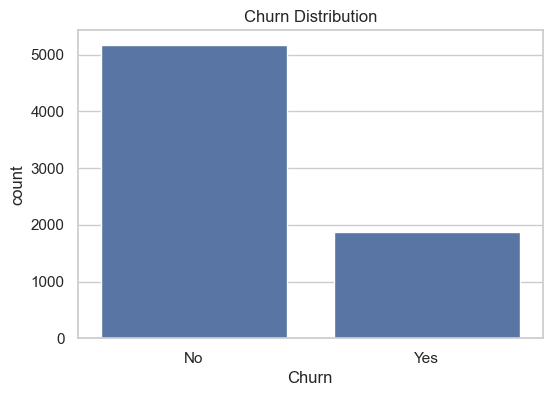

In [13]:
# ===============================
# 5. TARGET VARIABLE ANALYSIS
# ===============================
print("\nTarget Distribution:\n")
print(df["Churn"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


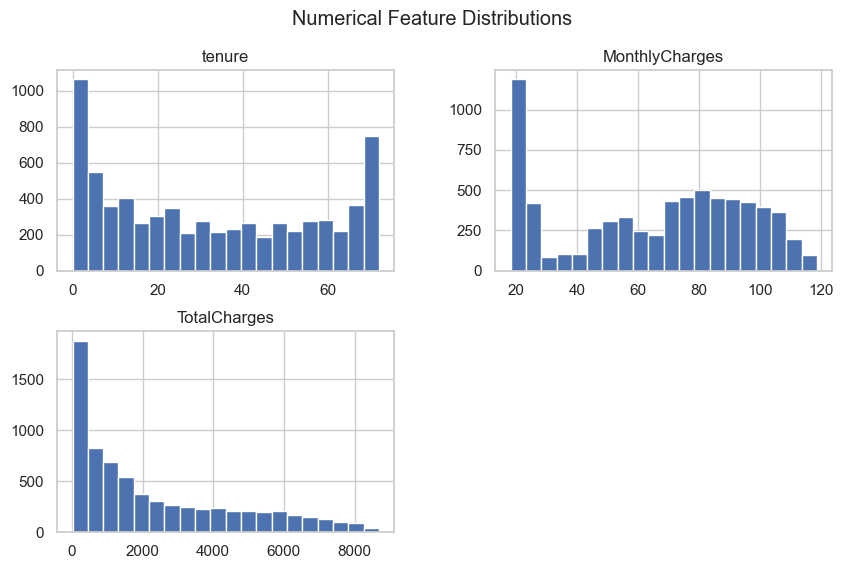

In [14]:
# ===============================
# 6. NUMERICAL FEATURES ANALYSIS
# ===============================
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[num_cols].hist(figsize=(10,6), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()


C:\Users\Saqib\AppData\Local\Temp\ipykernel_23336\3461161591.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


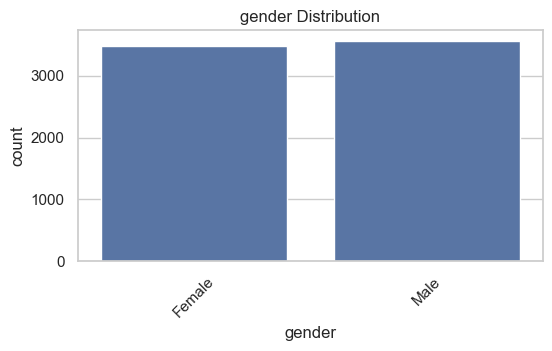

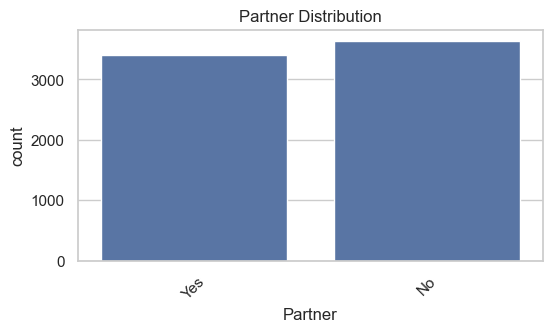

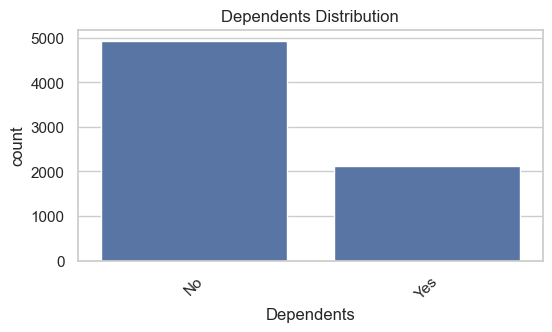

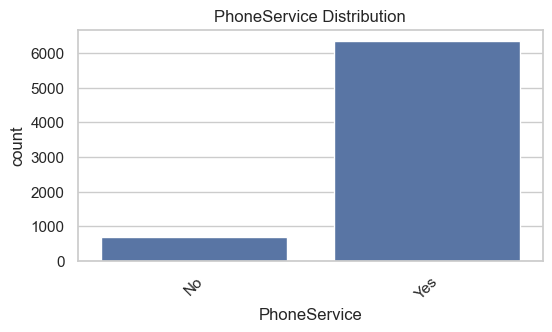

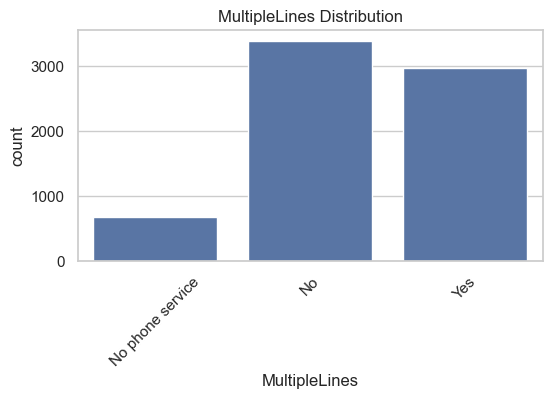

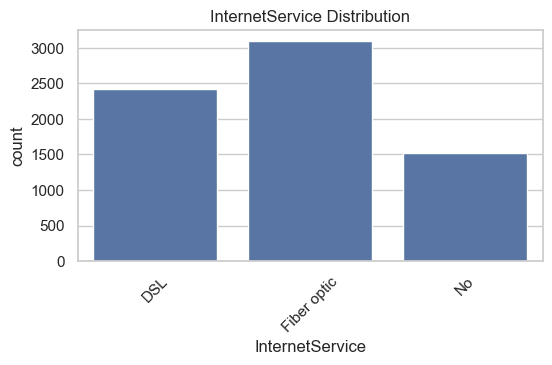

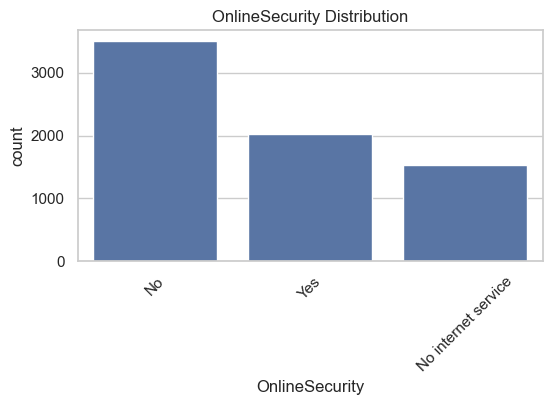

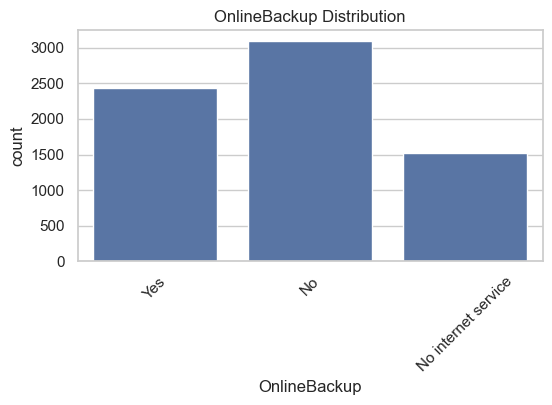

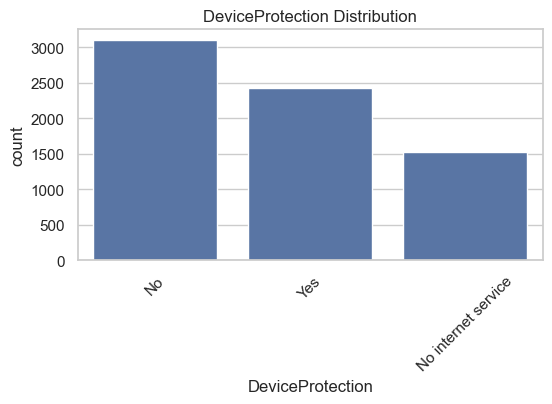

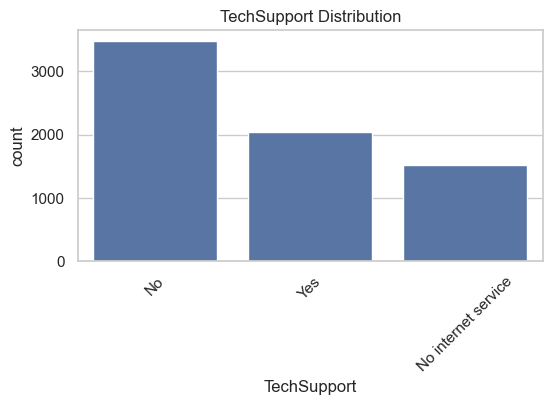

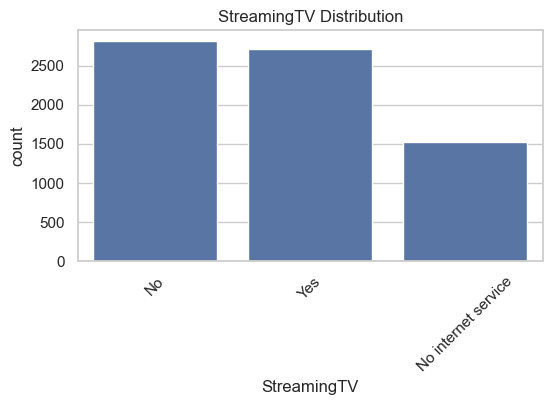

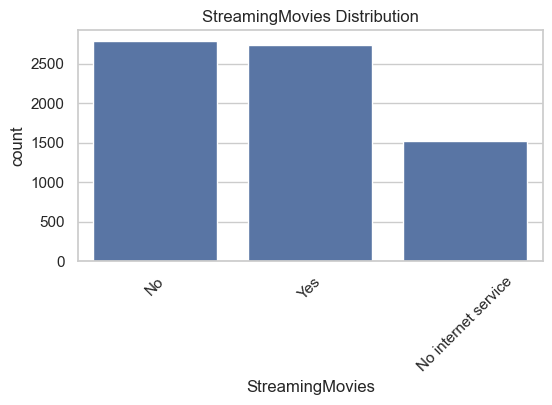

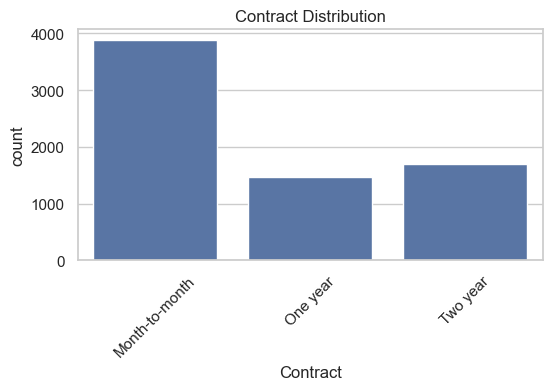

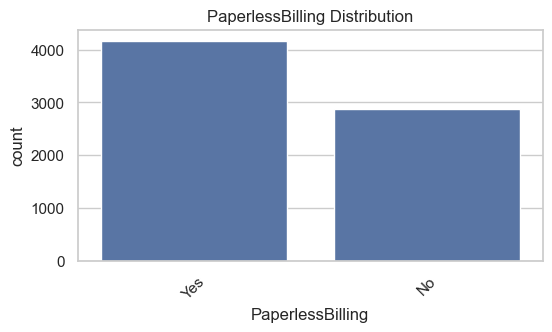

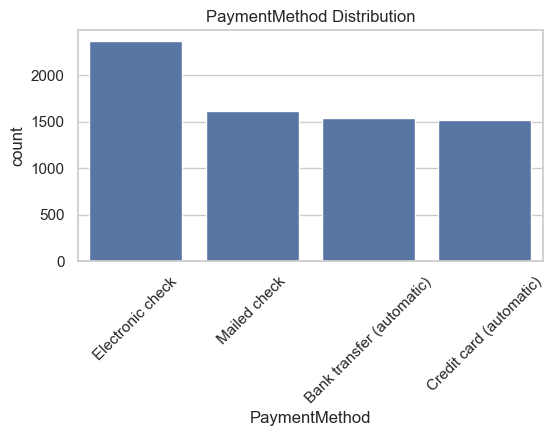

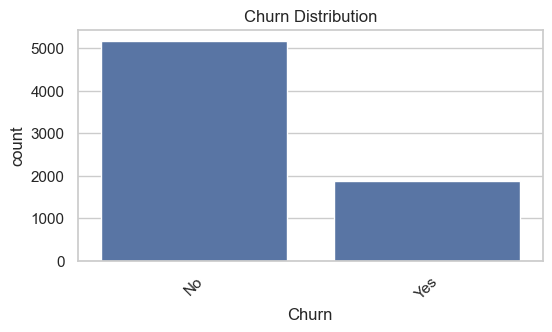

In [15]:
# ===============================
# 7. CATEGORICAL FEATURES ANALYSIS
# ===============================
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    if col != "customerID":
        plt.figure(figsize=(6,3))
        sns.countplot(x=col, data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} Distribution")
        plt.show()

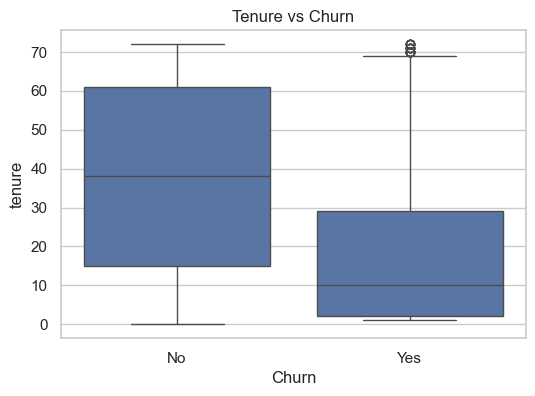

In [16]:
# ===============================
# 8. CHURN VS IMPORTANT FEATURES
# ===============================

# Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

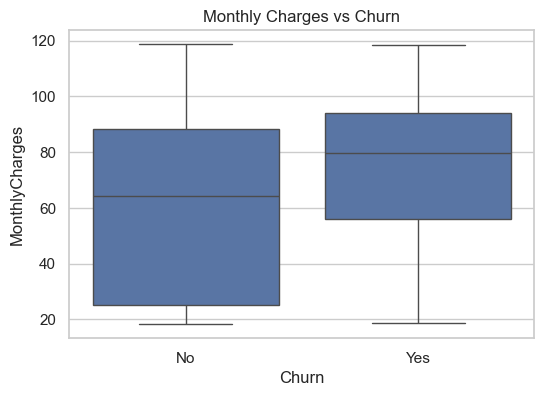

In [17]:
# Monthly Charges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


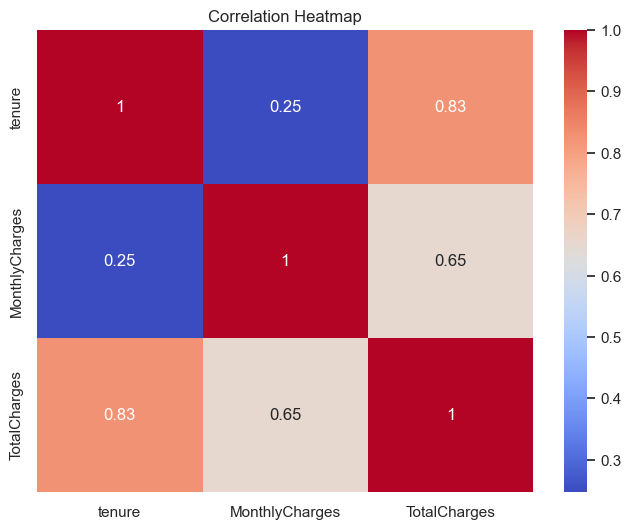

In [18]:
# ===============================
# 9. CORRELATION HEATMAP
# ===============================
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
# ===============================
# 10. SAVE CLEANED DATA
# ===============================
processed_path = os.path.join("..", "data", "processed", "cleaned_data.csv")
df.to_csv(processed_path, index=False)

print("\nCleaned data saved to:", processed_path)


Cleaned data saved to: ..\data\processed\cleaned_data.csv
